<a href="https://colab.research.google.com/github/abarnamagesh42/CodeAlpha_WebScraping/blob/main/CodeAlpha_WebScraping.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install requests beautifulsoup4 pandas matplotlib seaborn

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

In [ ]:
url = "https://realpython.github.io/fake-jobs/"
response = requests.get(url)
print(response.status_code)

200


In [ ]:
soup = BeautifulSoup(response.text, "html.parser")

In [ ]:
job_cards = soup.find_all("div", class_="card-content")
print("Total Jobs:", len(job_cards))

Total Jobs: 100


In [ ]:
titles = []
companies = []
locations = []

In [ ]:
for job in job_cards:
 title = job.find("h2").text.strip()
company = job.find("h3").text.strip()
location = job.find("p", class_="location").text.strip()
titles.append(title)
companies.append(company)
locations.append(location)

In [ ]:
df = pd.DataFrame({
    "Job Title": titles,
    "Company": companies,
    "Location": locations
})

df.head()

,Job Title,Company,Location
0,Ship broker,"Fuentes, Walls and Castro","Michelleville, AP"


In [ ]:
df.to_csv("job_market_data.csv", index=False)
print("CSV Saved Successfully")

CSV Saved Successfully


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1 entries, 0 to 0
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Job Title  1 non-null      object
 1   Company    1 non-null      object
 2   Location   1 non-null      object
dtypes: object(3)
memory usage: 156.0+ bytes


In [ ]:
df.shape

(1, 3)

In [ ]:
df.head()

,Job Title,Company,Location
0,Ship broker,"Fuentes, Walls and Castro","Michelleville, AP"


In [ ]:
df['Location'].value_counts().head(10)

,count
Location,
"Michelleville, AP",1


In [ ]:
df['Company'].value_counts().head(10)

,count
Company,
"Fuentes, Walls and Castro",1


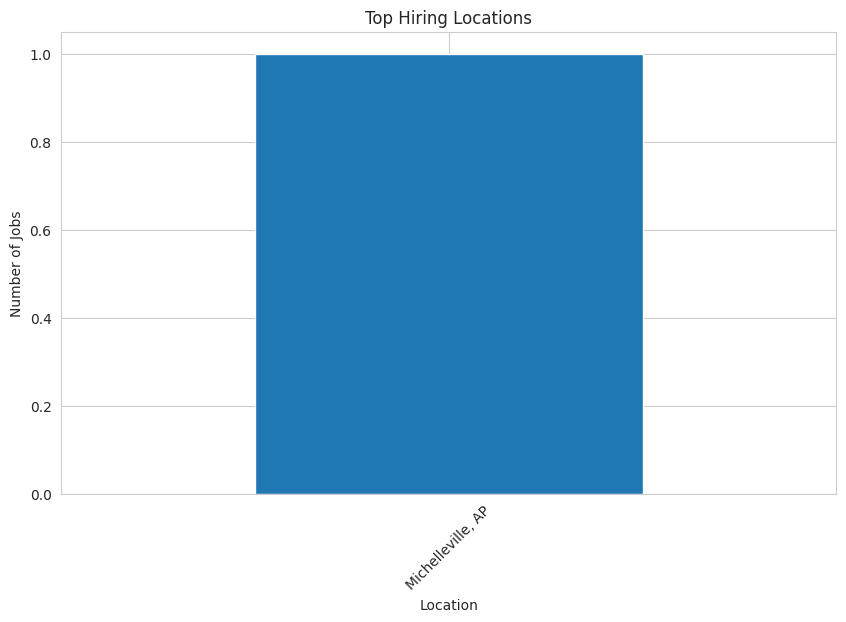

In [ ]:
plt.figure(figsize=(10,6))
df['Location'].value_counts().head(10).plot(kind='bar')
plt.title("Top Hiring Locations")
plt.xlabel("Location")
plt.ylabel("Number of Jobs")
plt.xticks(rotation=45)
plt.show()     ##The chart shows the locations with the highest number of job postings.Some cities appear more frequently than others###

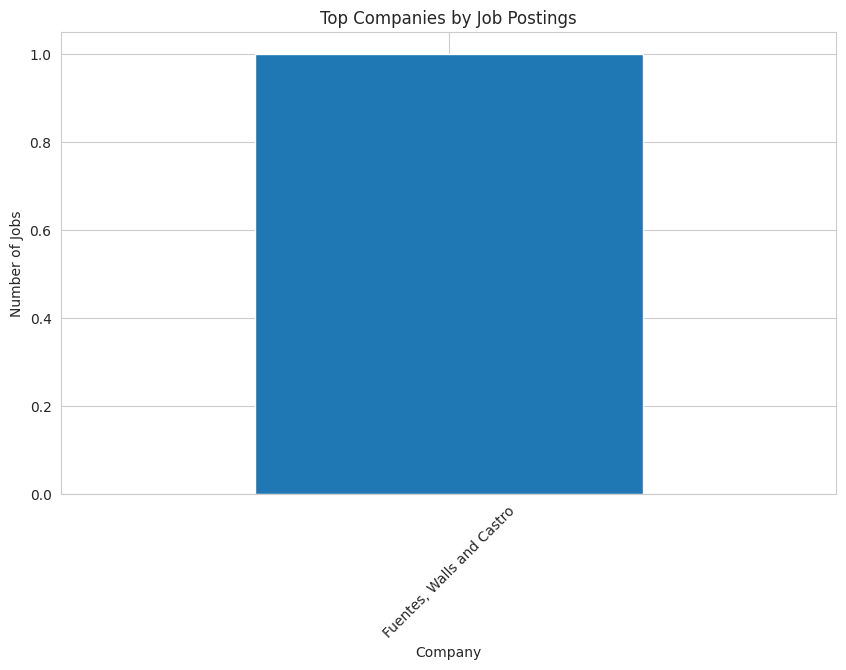

In [ ]:
plt.figure(figsize=(10,6))
df['Company'].value_counts().head(10).plot(kind='bar')
plt.title("Top Companies by Job Postings")
plt.xlabel("Company")
plt.ylabel("Number of Jobs")
plt.xticks(rotation=45)
plt.show()

# Key Insights

• Job opportunities are concentrated in a few locations.

• Certain companies are hiring more aggressively.

• Some job roles appear repeatedly, indicating demand in the market.

• Web scraping can automate collection of job market information for analysis.